In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [5]:
def run_hybrid_models(file_path, target_column='bug', smote_ratio=0.8):
    """
    Runs hybrid pipeline (SMOTE + undersampling + GridSearchCV)
    for SVM, KNN, and Logistic Regression.
    Records accuracy, precision, recall, f1, and AUC for each.
    """

    # -------------------------
    # Load and preprocess
    # -------------------------
    df = pd.read_csv(file_path)
    df = df.dropna()
    df[target_column] = df[target_column].apply(lambda x: 0 if x == 0 else 1)

    X = df.drop(columns=[target_column])
    y = df[target_column]

    print(f"\n==============================")
    print(f"Dataset: {file_path}")
    print("==============================")
    print("Original class distribution:")
    print(y.value_counts())

    # -------------------------
    # Define resampling steps
    # -------------------------
    smote = SMOTE(sampling_strategy=smote_ratio, random_state=42)
    undersample = RandomUnderSampler(sampling_strategy=1.0, random_state=42)

    # -------------------------
    # Define models and grids
    # -------------------------
    models = {
        'SVM': (
            SVC(probability=True, random_state=42),
            {
                'scaler': [StandardScaler()],
                'model__C': [0.1, 1, 10],
                'model__kernel': ['linear', 'rbf'],
                'model__gamma': ['scale', 'auto']
            }
        ),
        'KNN': (
            KNeighborsClassifier(),
            {
                'scaler': [StandardScaler()],
                'model__n_neighbors': [3, 5, 7, 9],
                'model__weights': ['uniform', 'distance'],
                'model__p': [1, 2]  # Manhattan / Euclidean
            }
        ),
        'LogisticRegression': (
            LogisticRegression(max_iter=1000, random_state=42),
            {
                'scaler': [StandardScaler()],
                'model__C': [0.01, 0.1, 1, 10],
                'model__penalty': ['l2'],
                'model__solver': ['lbfgs', 'saga']
            }
        )
    }

    results = []

    # -------------------------
    # Loop through models
    # -------------------------
    for model_name, (base_model, param_grid) in models.items():
        print(f"\n🔹 Training {model_name}...")

        # Define pipeline
        pipeline = Pipeline([
            ('smote', smote),
            ('under', undersample),
            ('scaler', StandardScaler()),
            ('model', base_model)
        ])

        # Adjust gridsearch to match pipeline naming
        param_grid = {k: v for k, v in param_grid.items() if k != 'scaler'}

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring='f1_macro',
            cv=5,
            n_jobs=-1,
            verbose=1
        )

        grid_search.fit(X, y)

        best_params = grid_search.best_params_
        best_score = grid_search.best_score_

        print(f"✅ Best Params for {model_name}: {best_params}")
        print(f"✅ Best CV F1 (macro): {best_score:.3f}")

        # -------------------------
        # Reapply resampling and train final model
        # -------------------------
        X_res, y_res = Pipeline([('smote', smote), ('under', undersample)]).fit_resample(X, y)

        X_train, X_test, y_train, y_test = train_test_split(
            X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
        )

        final_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', base_model.set_params(**{k.replace('model__', ''): v for k, v in best_params.items()}))
        ])

        final_pipeline.fit(X_train, y_train)

        y_pred = final_pipeline.predict(X_test)
        y_prob = final_pipeline.predict_proba(X_test)[:, 1] if hasattr(final_pipeline['model'], "predict_proba") else None

        # -------------------------
        # Metrics
        # -------------------------
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
        plt.title(f'Confusion Matrix - {model_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

        results.append({
            'Dataset': file_path,
            'Model': model_name,
            'Best Params': best_params,
            'CV F1': best_score,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-score': f1,
            'AUC': auc
        })

    # -------------------------
    # Save all results
    # -------------------------
    results_df = pd.DataFrame(results)
    print("\n================ RESULTS SUMMARY ================\n")
    print(results_df)

    return results_df


Running models for dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv

Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv
Original class distribution:
bug
0    1342
1     350
Name: count, dtype: int64

🔹 Training SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
✅ Best Params for SVM: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
✅ Best CV F1 (macro): 0.690

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.78      0.76       215
           1       0.77      0.73      0.75       215

    accuracy                           0.75       430
   macro avg       0.75      0.75      0.75       430
weighted avg       0.75      0.75      0.75       430



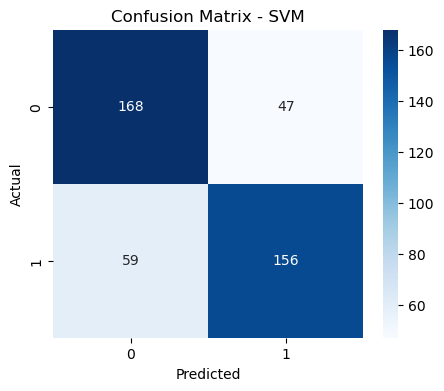


🔹 Training KNN...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
✅ Best Params for KNN: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}
✅ Best CV F1 (macro): 0.671

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       215
           1       0.82      0.85      0.84       215

    accuracy                           0.83       430
   macro avg       0.84      0.83      0.83       430
weighted avg       0.84      0.83      0.83       430



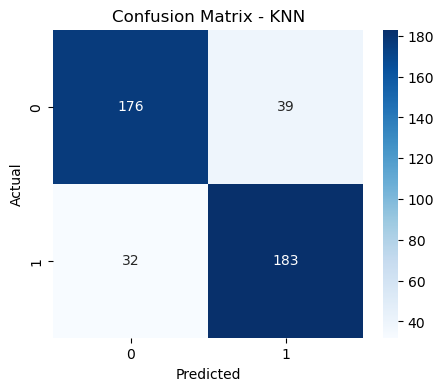


🔹 Training LogisticRegression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ Best Params for LogisticRegression: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
✅ Best CV F1 (macro): 0.697

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.81      0.76       215
           1       0.78      0.68      0.73       215

    accuracy                           0.75       430
   macro avg       0.75      0.75      0.75       430
weighted avg       0.75      0.75      0.75       430



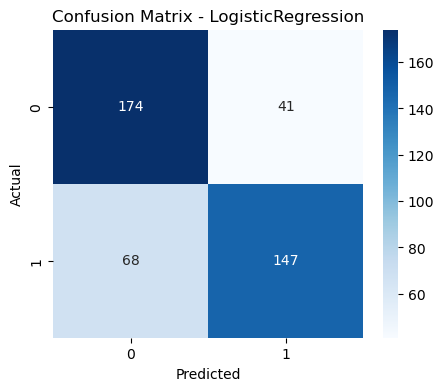


================ RESULTS SUMMARY ================

                                             Dataset               Model  \
0  C:\Users\sodhi\Desktop\Design Project\combined...                 SVM   
1  C:\Users\sodhi\Desktop\Design Project\combined...                 KNN   
2  C:\Users\sodhi\Desktop\Design Project\combined...  LogisticRegression   

                                         Best Params     CV F1  Accuracy  \
0  {'model__C': 1, 'model__gamma': 'scale', 'mode...  0.689755  0.753488   
1  {'model__n_neighbors': 9, 'model__p': 1, 'mode...  0.671004  0.834884   
2  {'model__C': 0.01, 'model__penalty': 'l2', 'mo...  0.697191  0.746512   

   Precision    Recall  F1-score       AUC  
0   0.768473  0.725581  0.746411  0.826458  
1   0.824324  0.851163  0.837529  0.884089  
2   0.781915  0.683721  0.729529  0.813088  

✅ Results saved to 'model_performance_summary.csv'
Running models for dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_2.csv

Dataset: C:\Users\sod

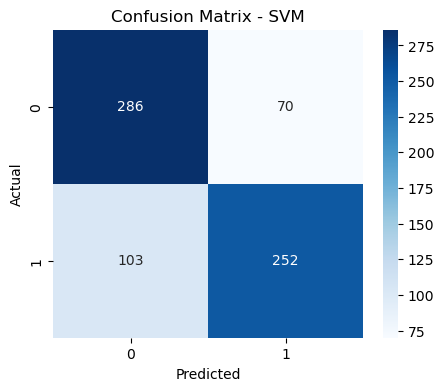


🔹 Training KNN...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
✅ Best Params for KNN: {'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'distance'}
✅ Best CV F1 (macro): 0.659

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.77      0.80       356
           1       0.78      0.83      0.81       355

    accuracy                           0.80       711
   macro avg       0.80      0.80      0.80       711
weighted avg       0.80      0.80      0.80       711



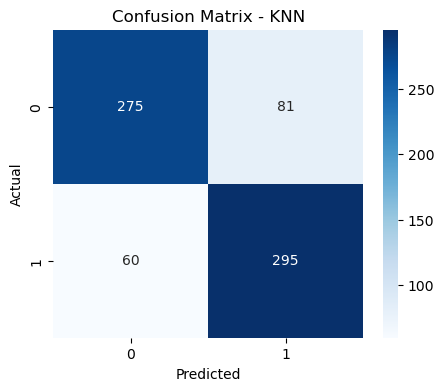


🔹 Training LogisticRegression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ Best Params for LogisticRegression: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
✅ Best CV F1 (macro): 0.581

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.69      0.66       356
           1       0.65      0.58      0.61       355

    accuracy                           0.64       711
   macro avg       0.64      0.64      0.64       711
weighted avg       0.64      0.64      0.64       711



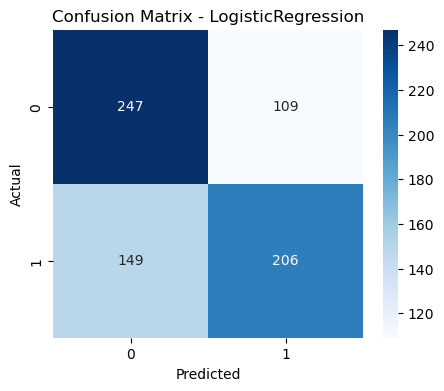


================ RESULTS SUMMARY ================

                                             Dataset               Model  \
0  C:\Users\sodhi\Desktop\Design Project\combined...                 SVM   
1  C:\Users\sodhi\Desktop\Design Project\combined...                 KNN   
2  C:\Users\sodhi\Desktop\Design Project\combined...  LogisticRegression   

                                         Best Params     CV F1  Accuracy  \
0  {'model__C': 10, 'model__gamma': 'scale', 'mod...  0.626495  0.756681   
1  {'model__n_neighbors': 3, 'model__p': 1, 'mode...  0.658530  0.801688   
2  {'model__C': 0.01, 'model__penalty': 'l2', 'mo...  0.581424  0.637131   

   Precision    Recall  F1-score       AUC  
0   0.782609  0.709859  0.744461  0.842974  
1   0.784574  0.830986  0.807114  0.859404  
2   0.653968  0.580282  0.614925  0.696954  

✅ Results saved to 'model_performance_summary.csv'
Running models for dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_3.csv

Dataset: C:\Users\sod

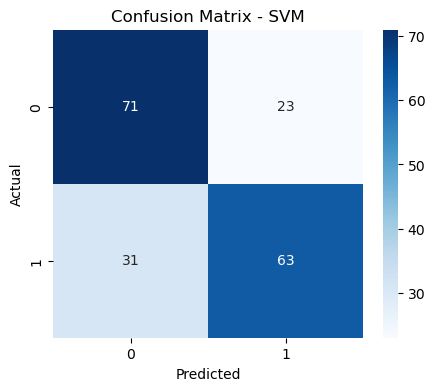


🔹 Training KNN...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
✅ Best Params for KNN: {'model__n_neighbors': 3, 'model__p': 2, 'model__weights': 'distance'}
✅ Best CV F1 (macro): 0.623

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.84        94
           1       0.82      0.87      0.85        94

    accuracy                           0.84       188
   macro avg       0.84      0.84      0.84       188
weighted avg       0.84      0.84      0.84       188



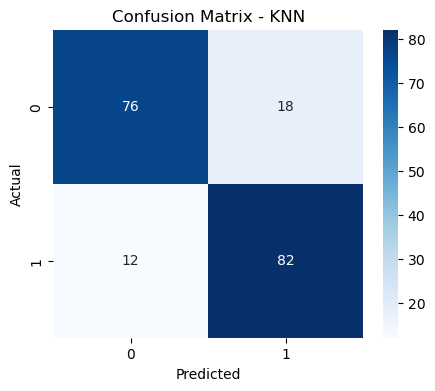


🔹 Training LogisticRegression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ Best Params for LogisticRegression: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
✅ Best CV F1 (macro): 0.576

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.72      0.68        94
           1       0.68      0.59      0.63        94

    accuracy                           0.65       188
   macro avg       0.66      0.65      0.65       188
weighted avg       0.66      0.65      0.65       188



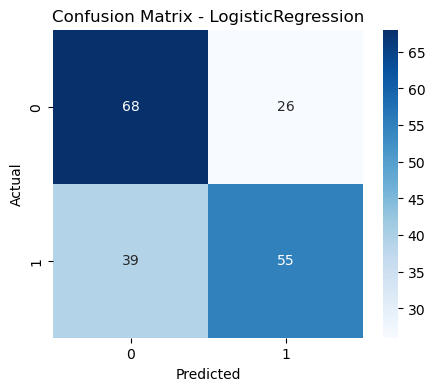


================ RESULTS SUMMARY ================

                                             Dataset               Model  \
0  C:\Users\sodhi\Desktop\Design Project\combined...                 SVM   
1  C:\Users\sodhi\Desktop\Design Project\combined...                 KNN   
2  C:\Users\sodhi\Desktop\Design Project\combined...  LogisticRegression   

                                         Best Params     CV F1  Accuracy  \
0  {'model__C': 0.1, 'model__gamma': 'scale', 'mo...  0.585486  0.712766   
1  {'model__n_neighbors': 3, 'model__p': 2, 'mode...  0.623370  0.840426   
2  {'model__C': 0.01, 'model__penalty': 'l2', 'mo...  0.576180  0.654255   

   Precision    Recall  F1-score       AUC  
0   0.732558  0.670213  0.700000  0.791874  
1   0.820000  0.872340  0.845361  0.906010  
2   0.679012  0.585106  0.628571  0.754527  

✅ Results saved to 'model_performance_summary.csv'
Running models for dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv

Dataset: C:\Users\sod

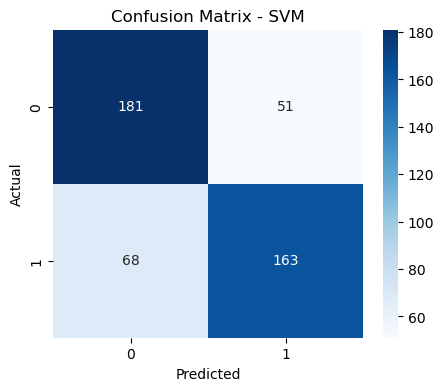


🔹 Training KNN...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
✅ Best Params for KNN: {'model__n_neighbors': 7, 'model__p': 1, 'model__weights': 'distance'}
✅ Best CV F1 (macro): 0.680

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       232
           1       0.83      0.93      0.88       231

    accuracy                           0.87       463
   macro avg       0.88      0.87      0.87       463
weighted avg       0.88      0.87      0.87       463



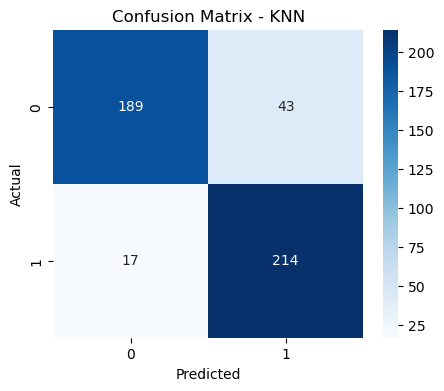


🔹 Training LogisticRegression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ Best Params for LogisticRegression: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
✅ Best CV F1 (macro): 0.658

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       232
           1       0.76      0.74      0.75       231

    accuracy                           0.75       463
   macro avg       0.75      0.75      0.75       463
weighted avg       0.75      0.75      0.75       463



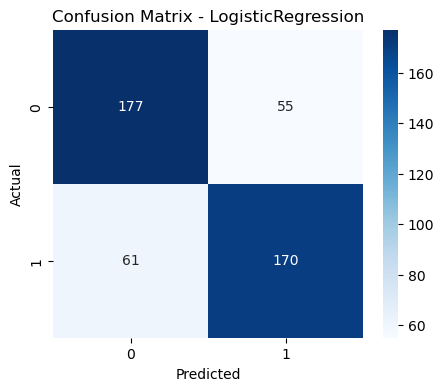


================ RESULTS SUMMARY ================

                                             Dataset               Model  \
0  C:\Users\sodhi\Desktop\Design Project\combined...                 SVM   
1  C:\Users\sodhi\Desktop\Design Project\combined...                 KNN   
2  C:\Users\sodhi\Desktop\Design Project\combined...  LogisticRegression   

                                         Best Params     CV F1  Accuracy  \
0  {'model__C': 10, 'model__gamma': 'scale', 'mod...  0.661520  0.742981   
1  {'model__n_neighbors': 7, 'model__p': 1, 'mode...  0.680120  0.870410   
2  {'model__C': 1, 'model__penalty': 'l2', 'model...  0.657829  0.749460   

   Precision    Recall  F1-score       AUC  
0   0.761682  0.705628  0.732584  0.825123  
1   0.832685  0.926407  0.877049  0.924840  
2   0.755556  0.735931  0.745614  0.823985  

✅ Results saved to 'model_performance_summary.csv'
Running models for dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_5.csv

Dataset: C:\Users\sod

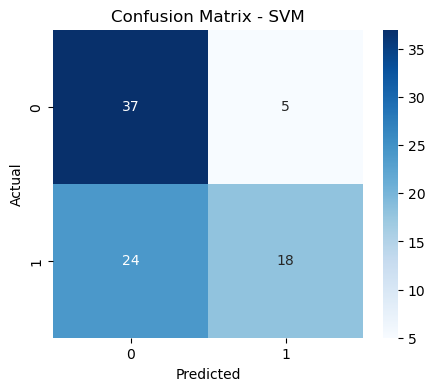


🔹 Training KNN...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
✅ Best Params for KNN: {'model__n_neighbors': 7, 'model__p': 1, 'model__weights': 'uniform'}
✅ Best CV F1 (macro): 0.625

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.83      0.71        42
           1       0.75      0.50      0.60        42

    accuracy                           0.67        84
   macro avg       0.69      0.67      0.66        84
weighted avg       0.69      0.67      0.66        84



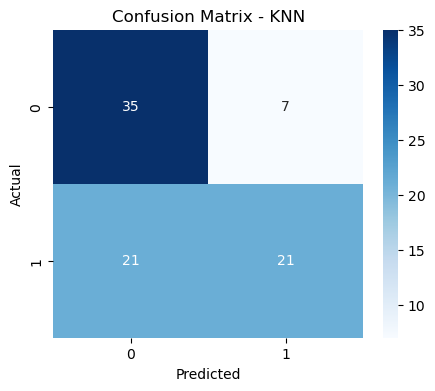


🔹 Training LogisticRegression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ Best Params for LogisticRegression: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
✅ Best CV F1 (macro): 0.638

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.83      0.70        42
           1       0.73      0.45      0.56        42

    accuracy                           0.64        84
   macro avg       0.67      0.64      0.63        84
weighted avg       0.67      0.64      0.63        84



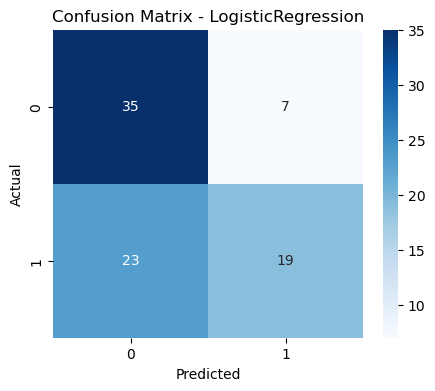


================ RESULTS SUMMARY ================

                                             Dataset               Model  \
0  C:\Users\sodhi\Desktop\Design Project\combined...                 SVM   
1  C:\Users\sodhi\Desktop\Design Project\combined...                 KNN   
2  C:\Users\sodhi\Desktop\Design Project\combined...  LogisticRegression   

                                         Best Params     CV F1  Accuracy  \
0  {'model__C': 0.1, 'model__gamma': 'scale', 'mo...  0.648032  0.654762   
1  {'model__n_neighbors': 7, 'model__p': 1, 'mode...  0.625082  0.666667   
2  {'model__C': 0.1, 'model__penalty': 'l2', 'mod...  0.637969  0.642857   

   Precision    Recall  F1-score       AUC  
0   0.782609  0.428571  0.553846  0.670918  
1   0.750000  0.500000  0.600000  0.708050  
2   0.730769  0.452381  0.558824  0.672052  

✅ Results saved to 'model_performance_summary.csv'


Dataset  \
Dataset                                            Model                                                      
C:\Users\sodhi\Desktop\Design Project\combined\... 0      C:\Users\sodhi\Desktop\Design Project\combined...   
                                                   1      C:\Users\sodhi\Desktop\Design Project\combined...   
                                                   2      C:\Users\sodhi\Desktop\Design Project\combined...   
C:\Users\sodhi\Desktop\Design Project\combined\... 0      C:\Users\sodhi\Desktop\Design Project\combined...   
                                                   1      C:\Users\sodhi\Desktop\Design Project\combined...   
                                                   2      C:\Users\sodhi\Desktop\Design Project\combined...   
C:\Users\sodhi\Desktop\Design Project\combined\... 0      C:\Users\sodhi\Desktop\Design Project\combined...   
                                                   1      C:\Users\sodhi\Desktop\Design Project\combined...   
                                                   2      C:\Users\sodhi\Desktop\Design Project\combined...   
C:\Users\sodhi\Desktop\Design Project\combined\... 0      C:\Users\sodhi\Desktop\Design Project\combined...   
                                                   1      C:\Users\sodhi\Desktop\Design Project\combined...   
                                                   2      C:\Users\sodhi\Desktop\Design Project\combined...   
C:\Users\sodhi\Desktop\Design Project\combined\... 0      C:\Users\sodhi\Desktop\Design Project\combined...   
                                                   1      C:\Users\sodhi\Desktop\Design Project\combined...   
                                                   2      C:\Users\sodhi\Desktop\Design Project\combined...   

                                                                       Model  \
Dataset                                            Model                       
C:\Users\sodhi\Desktop\Design Project\combined\... 0                     SVM   
                                                   1                     KNN   
                                                   2      LogisticRegression   
C:\Users\sodhi\Desktop\Design Project\combined\... 0                     SVM   
                                                   1                     KNN   
                                                   2      LogisticRegression   
C:\Users\sodhi\Desktop\Design Project\combined\... 0                     SVM   
                                                   1                     KNN   
                                                   2      LogisticRegression   
C:\Users\sodhi\Desktop\Design Project\combined\... 0                     SVM   
                                                   1                     KNN   
                                                   2      LogisticRegression   
C:\Users\sodhi\Desktop\Design Project\combined\... 0                     SVM   
                                                   1                     KNN   
                                                   2      LogisticRegression   

                                                                                                Best Params  \
Dataset                                            Model                                                      
C:\Users\sodhi\Desktop\Design Project\combined\... 0      {'model__C': 1, 'model__gamma': 'scale', 'mode...   
                                                   1      {'model__n_neighbors': 9, 'model__p': 1, 'mode...   
                                                   2      {'model__C': 0.01, 'model__penalty': 'l2', 'mo...   
C:\Users\sodhi\Desktop\Design Project\combined\... 0      {'model__C': 10, 'model__gamma': 'scale', 'mod...   
                                                   1      {'model__n_neighbors': 3, 'model__p': 1, 'mode...   
                                                   2      {'model__C': 0.0

In [15]:
file_paths = [
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_2.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_3.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_5.csv"
]

# Store all results
all_results = {}

for fp in file_paths:
    print("="*80)
    print(f"Running models for dataset: {fp}")
    print("="*80)
    
    # Run the hybrid pipeline (SVM, KNN, Logistic Regression)
    results_df = run_hybrid_models(fp, target_column='bug')
    
    # Store results for each dataset
    all_results[fp] = results_df

# Combine all results into one table
final_results = pd.concat(all_results.values(), keys=all_results.keys(), names=['Dataset', 'Model'])
display(final_results)
